<a href="https://colab.research.google.com/github/epears04/DATA-4620-HW3/blob/main/DATA_4620_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import torch
import os
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm, trange

from sklearn.model_selection import train_test_split

In [5]:
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
!wget -q -nc -O facial_keypoints.npz "https://www.dropbox.com/scl/fi/27qggijmythfjg04s24xq/facial_keypoints.npz?rlkey=h91gwodhrfuz8hrc7ux9qnq7s&dl=1"

In [7]:
data = np.load('facial_keypoints.npz')
images = data['images']
keypoints = data['keypoints']

In [8]:
def masked_mae_loss(y_pred: torch.Tensor, y_true: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """ Compute masked mean absolute error (MAE) loss, ignoring NaN values.
        This function returns the numerator and denominator separately;
        the loss is calculated as num/den.

        To calculate the average loss over batches, you should
        separately sum the numerators and demoninators,
        and then divide: total_num / total_den.

        Arguments:
            y_pred: predicted keypoints [B,C]
            y_true: ground truth keypoints (may contain NaNs) [B,C]

        Returns:
            numerator, denominator of MAE
    """
    mask = 1-torch.isnan(y_true).float()
    diff = torch.abs(y_true-y_pred)
    return torch.nansum(diff*mask), torch.nansum(mask)

Inspect the data. Print out the shape, dtype, min, and max of the arrays and explain them in your report. Show some of the images and plot the keypoint locations on top of the images. Note: You can use np.nanmin() and np.nanmax() to compute the min and max while ignoring the missing values.

In [9]:
print("Images data:")
print(f" - {images.shape}")
print(f" - {images.dtype}")
print(f" - Min: {np.nanmin(images)}")
print(f" - Max: {np.nanmax(images)}")
print("Keypoints data:")
print(f" - {keypoints.shape}")
print(f" - {keypoints.dtype}")
print(f" - Min: {np.nanmin(keypoints)}")
print(f" - Max: {np.nanmax(keypoints)}")

Images data:
 - (7049, 1, 96, 96)
 - int64
 - Min: 0
 - Max: 255
Keypoints data:
 - (7049, 30)
 - float32
 - Min: 0.6865919828414917
 - Max: 95.9356460571289


In [63]:
import cv2
import matplotlib.pyplot as plt

def plot_image(image, image_keypoints):
    image = image.reshape(96, 96)

    keypoints_x = image_keypoints[::2]
    keypoints_y = image_keypoints[1::2]

    plt.imshow(image, cmap='gray')
    plt.scatter(keypoints_x, keypoints_y, color='green', marker='o')
    plt.axis('off')
    plt.show()

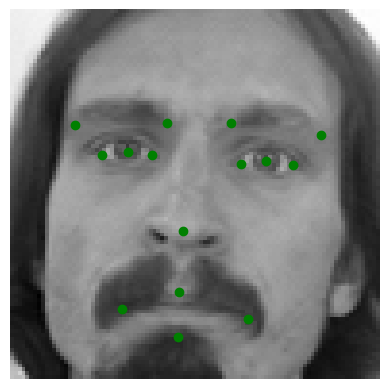

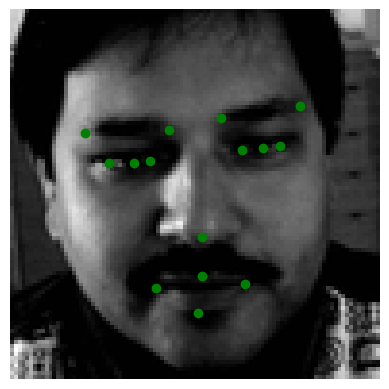

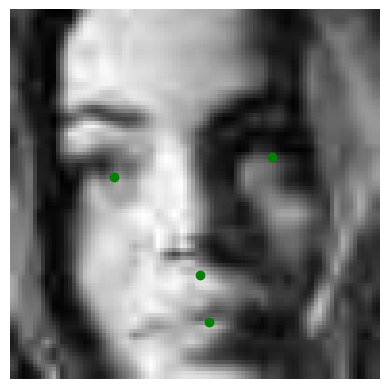

In [64]:
plot_image(images[0], keypoints[0])
plot_image(images[200], keypoints[200])
plot_image(images[4620], keypoints[4620])